In [48]:
import os
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.signal import savgol_filter

plt.style.use('bmh')

In [49]:
ruta = "/Users/andresitoortiz/Library/Mobile Documents/com~apple~CloudDocs/Pregrado_Fisica/2025-2/Lab_intermedio/Franck-Hertz/FranckHertz/Actividad_2"
data = {}
for archivo in glob.glob(os.path.join(ruta, "*.csv")):
    nombre = os.path.basename(archivo)
    df = pd.read_csv(archivo, delimiter=';')
    df = df.replace(',', '.', regex=True)
    data[nombre] = df

print("Archivos cargados:", list(data.keys()))
keys=list(data.keys())
print(keys)
print(data.values())

Archivos cargados: ['2_180.csv', '2_185.csv', '2_175.csv', '2_170.csv', '2_165.csv']
['2_180.csv', '2_185.csv', '2_175.csv', '2_170.csv', '2_165.csv']
dict_values([     Voltage U1 Corriente IA
0          U1/V        IA/nA
1           NaN          NaN
2          0.02         0.39
3          0.04          0.4
4          0.07         0.41
...         ...          ...
2454       59.9         5.62
2455      59.92         5.69
2456      59.95         5.73
2457      59.97         5.79
2458      59.99         5.81

[2459 rows x 2 columns],      Voltage U1 Corriente IA
0          U1/V        IA/nA
1           NaN          NaN
2          0.02          0.4
3          0.04         0.42
4          0.07         0.44
...         ...          ...
2454       59.9         1.93
2455      59.92         1.95
2456      59.95         1.96
2457      59.97         1.96
2458      59.99         1.98

[2459 rows x 2 columns],      Voltage U1 Corriente IA
0          U1/V        IA/nA
1           NaN          NaN
2

In [ ]:
solarized_colors = [
    "#268BD2",  # azul
    "#2AA198",  # verde-azulado
    "#859900",  # verde amarillento
    "#CB4B16",
    "#B58900",  # naranja profundo  # rojo
    "#DC322F",  # amarillo tostado
    "#6C71C4",  # púrpura
    "#586E75"   # gris azulado
]

solarized_figures = [
    's',
    'o',
    '^'
]

In [ ]:
def minimos_por_ventanas(V, I, vmin=20, vmax=60, ancho=5):
    # Filtrar región de interés
    mask = (V >= vmin) & (V <= vmax)
    Vp = V[mask]
    Ip = I[mask]

    min_V = []
    min_I = []

    # Recorrer la región en ventanas de 5V
    v_actual = vmin
    while v_actual < vmax:
        v_next = v_actual + ancho

        # Seleccionar puntos dentro de la ventana
        wmask = (Vp >= v_actual) & (Vp < v_next)
        Vw = Vp[wmask]
        Iw = Ip[wmask]

        if len(Iw) > 0:
            # Obtener el mínimo absoluto dentro de la ventana
            idx = np.argmin(Iw)
            min_V.append(Vw[idx])
            min_I.append(Iw[idx])

        v_actual = v_next

    return np.array(min_V), np.array(min_I)

resultados = {}

for nombre, df in data.items():
    V = pd.to_numeric(df["Voltage U1"], errors="coerce").to_numpy()
    I = pd.to_numeric(df["Corriente IA"], errors="coerce").to_numpy()

    Vmin, Imin = minimos_por_ventanas(V, I, vmin=20, vmax=60, ancho=5)
    
    resultados[nombre] = (Vmin, Imin)
    print(f"{nombre}: {len(Vmin)} mínimos encontrados")
    


2_180.csv: 8 mínimos encontrados
2_185.csv: 8 mínimos encontrados
2_175.csv: 8 mínimos encontrados
2_170.csv: 8 mínimos encontrados
2_165.csv: 8 mínimos encontrados


In [38]:
print(resultados['2_165.csv'])

minimos = {}
for key in resultados.keys():
    minimos[key] = resultados[key][0]

print(minimos)

(array([20.51, 25.03, 30.03, 35.04, 44.05, 48.91, 53.72, 58.77]), array([0.84, 1.1 , 1.42, 1.84, 2.26, 2.73, 3.27, 4.05]))
{'2_180.csv': array([20.14, 25.29, 30.06, 35.01, 43.95, 48.96, 53.79, 58.73]), '2_185.csv': array([20.65, 25.81, 30.23, 35.21, 40.02, 45.03, 54.33, 59.09]), '2_175.csv': array([20.31, 25.37, 30.08, 35.01, 43.95, 48.76, 53.65, 58.6 ]), '2_170.csv': array([20.02, 25.  , 30.01, 35.01, 43.95, 48.86, 53.69, 58.65]), '2_165.csv': array([20.51, 25.03, 30.03, 35.04, 44.05, 48.91, 53.72, 58.77])}


In [45]:
def diferencias_minimos(dic_minimos):
    dic_deltas = {}

    for T, Vmins in dic_minimos.items():
        Vmins = np.array(Vmins)
        difs = np.diff(Vmins)   # diferencias consecutivas

        # Crear dict interno: n: diferencia
        dic_deltas[T] = {n+1: difs[n] for n in range(len(difs))}

    return dic_deltas


deltas = diferencias_minimos(minimos)
print(deltas['2_185.csv'])

{1: np.float64(5.16), 2: np.float64(4.420000000000002), 3: np.float64(4.98), 4: np.float64(4.810000000000002), 5: np.float64(5.009999999999998), 6: np.float64(9.299999999999997), 7: np.float64(4.760000000000005)}



### Resultados para T = 175 °C ###
a = -0.003714 ± 0.028861
b = 4.904667 ± 0.112397

### Resultados para T = 180 °C ###
a = -0.023143 ± 0.032086
b = 5.022667 ± 0.124958

### Resultados para T = 185 °C ###
a = -0.011429 ± 0.061684
b = 4.896667 ± 0.240226


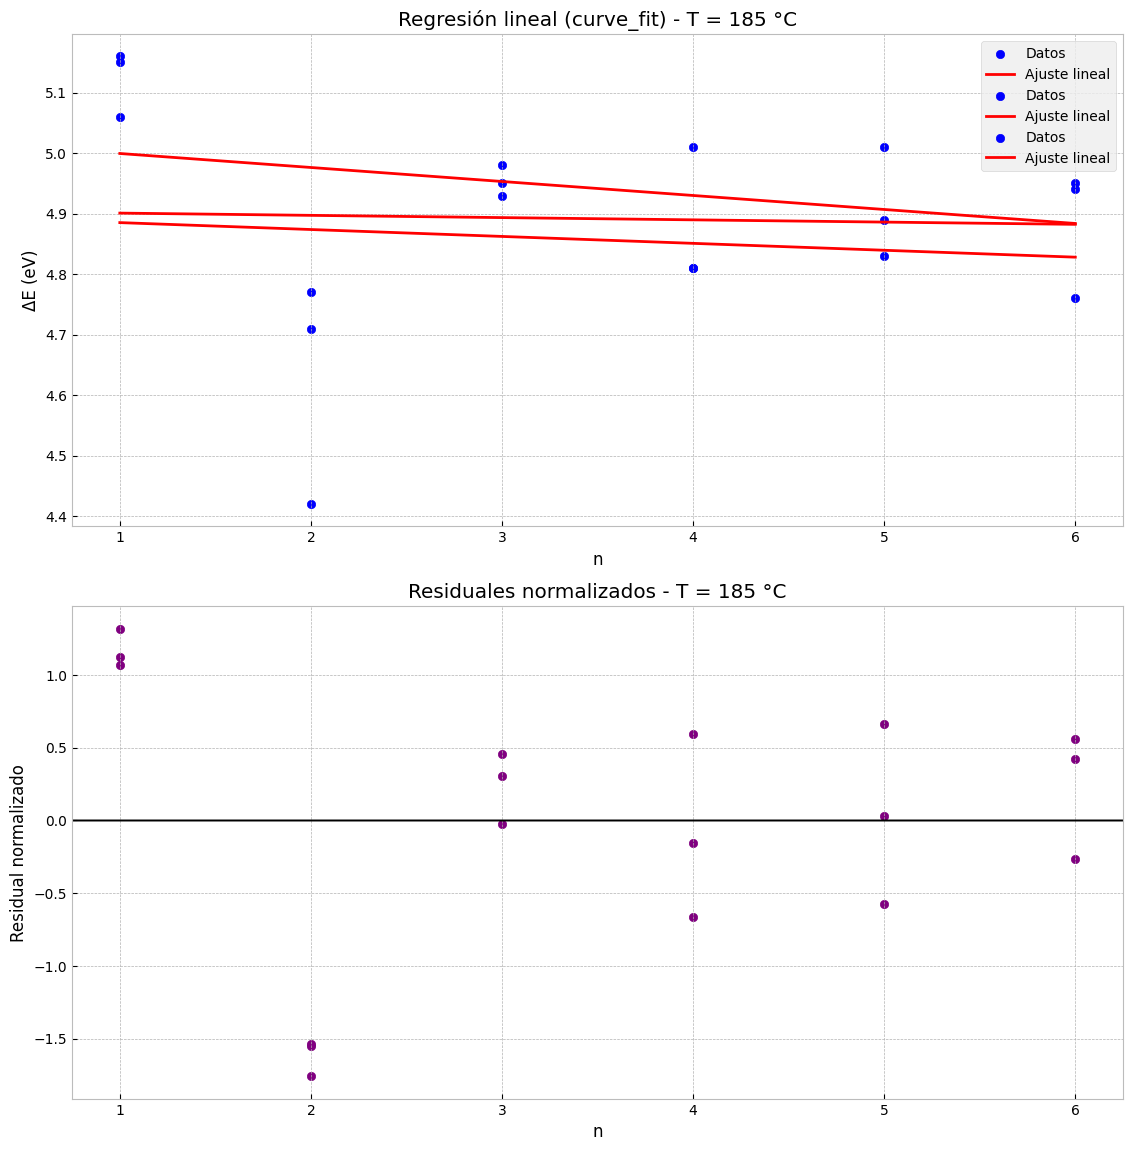

In [ ]:
# Función lineal para el ajuste
def funcion_lineal(x, a, b):
    return a * x + b

# --- Datos de las últimas 3 temperaturas ---
deltas = {
    175: [5.06, 4.71, 4.93, 4.81, 4.89, 4.95],
    180: [5.15, 4.77, 4.95, 5.01, 4.83, 4.94],
    185: [5.16, 4.42, 4.98, 4.81, 5.01, 4.76]
}

fig, axs = plt.subplots(2, 1, figsize=(12, 12))
axs[0].set_facecolor("#FFFFFF")
axs[1].set_facecolor("#FFFFFF")
plt.tight_layout(pad=4)

for idx, T in enumerate([175, 180, 185]):

    ydata = np.array(deltas[T], dtype=float)
    xdata = np.arange(1, len(ydata) + 1, dtype=float)

    # Sigma = desviación estándar estimada para normalizar
    sigma_y = np.std(ydata, ddof=1) * np.ones_like(ydata)

    # Ajuste lineal con curve_fit
    popt, pcov = curve_fit(
        funcion_lineal,
        xdata,
        ydata,
        sigma=sigma_y,
        absolute_sigma=True
    )

    a, b = popt
    perr = np.sqrt(np.diag(pcov))
    a_err, b_err = perr

    print(f"a = {a:.6f} ± {a_err:.6f}")
    print(f"b = {b:.6f} ± {b_err:.6f}")

    # Valores ajustados
    yfit = funcion_lineal(xdata, *popt)

    # Residuales normalizados
    residuales = (ydata - yfit) / sigma_y

    # ======= GRÁFICO DE REGRESIÓN =======
    
    axs[0].errorbar(xdata, ydata, color=solarized_colors[idx], marker = solarized_figures[idx], label='Datos')
    axs[0].errorbar(xdata,ydata,
        xerr=0, yerr=0.01,
        fmt=solarized_figures[idx],color = solarized_colors[idx] , markersize = 5, markeredgewidth = 0.5, markeredgecolor = 'k',
        capsize = 2, elinewidth = 1, ecolor = 'k',
        label=fr'$(d\Delta E/dn)_{idx} = {a:.6f} ± {a_err:.6f} $')
    axs[0].plot(xdata, yfit, color='red')
    axs[0].set_title(f'Regresión lineal (curve_fit) - T = {T} °C')
    axs[0].set_xlabel('n')
    axs[0].set_ylabel('ΔE (eV)')
    axs[0].grid(True)
    axs[0].legend()

    # ======= GRÁFICO DE RESIDUALES NORMALIZADOS =======
    
    axs[1].axhline(0, color='black', linewidth=1)
    axs[1].scatter(xdata, residuales, color='purple')
    axs[1].set_title(f'Residuales normalizados - T = {T} °C')
    axs[1].set_xlabel('n')
    axs[1].set_ylabel('Residual normalizado')
    axs[1].grid(True)

plt.show()

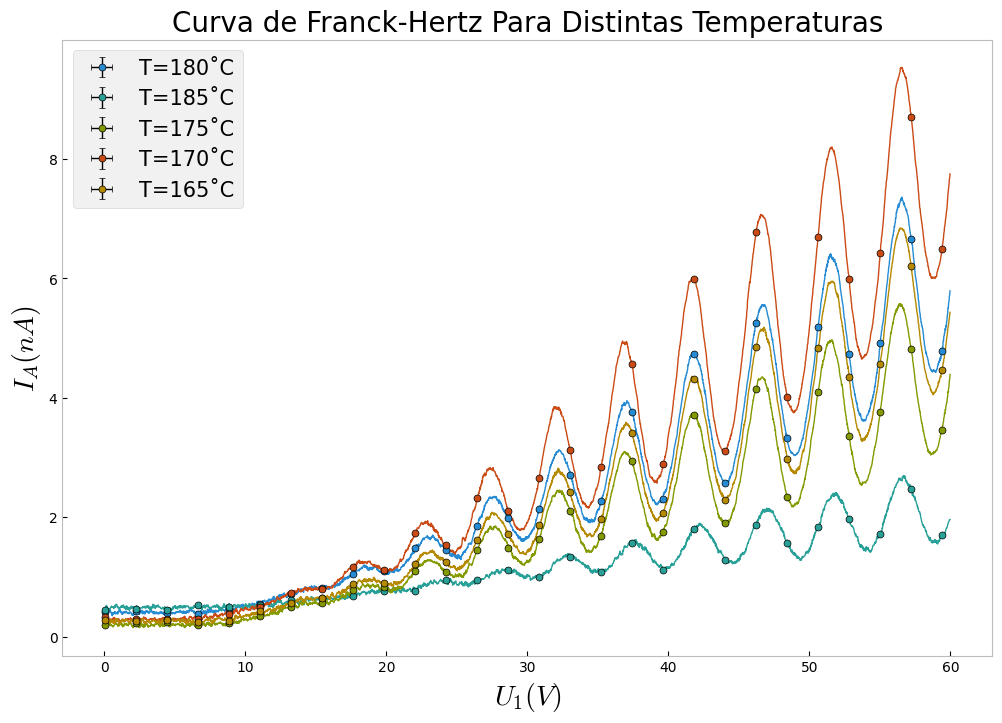

In [16]:
fig,axes = plt.subplots(1,figsize=(12,8))
axes.set_facecolor("#FFFFFF")
i=0

for df in data.values():
    dff = df[2:-1].astype(float)
    x = dff["Voltage U1"]
    y = dff["Corriente IA"]
    
    axes.errorbar(x[2:-1:90], y[2:-1:90],
        xerr=0.01, yerr=0.01,
        fmt='o',color = solarized_colors[i] , markersize = 5, markeredgewidth = 0.5, markeredgecolor = 'k',
        capsize = 2, elinewidth = 1, ecolor = 'k',
        label=f'T={keys[i][2:5]}˚C')
    axes.plot(x, y, color = solarized_colors[i], linewidth = 1)
    
    i+=1
axes.set_title("Curva de Franck-Hertz Para Distintas Temperaturas", fontsize=20)
axes.set_xlabel(fr"$U_1 (V)$", fontsize=20)
axes.set_ylabel(fr"$I_A (nA)$", fontsize=20)
plt.legend(fontsize=15)
plt.grid(False)    
plt.savefig("Curvas_Franck_Hertz_Temperaturas.png", dpi=300)
plt.show()